<p style="font-weight: bolder;">Universidad Santo Tom&aacute;s<br/>Electiva II - Miner&iacute;a y An&aacute;litica de Datos<br/>Ingrid Tatiana G&oacute;mez Gamboa</p>

### **Metodología CRISP-DM**

### **1. Comprensión del Negocio**

Contexto del Negocio: Una empresa requiere reducir la rotaciòn del personal, porque perder empleados genera costos de reclutamiento, capacitaciòn y pérdida de conocimiento. La Organización requiere anticiparse a estas salidas. 

Objetivo del Negocio: Predecir si un empleado tiene riesgo de abandonar la empresa (Attrition = Yes) usando sus características laborales y personales, con el fin que el área de Recursos Humanos pueda intervenir de forma preventiva. 

Objetivo del Análisis: Contruir un modelo de clasificación binaria que prediga la variable Attrition (Yes/No) a partir de 34 variables predictoras del conjunto de datos Human_Resources.csv

Criterios de Éxito: Accuracy >= 80%  -  F1-Score aceptable para la clase minoritaria (Yes), dado que hay desbalance de clases (Solo el 16% de los registros son retiros de empleados de la empresa) - El modelo debe identificar correctamente los empleados en riesgo (Priorizar recall sobre la clase Yes)

Restricciones y Consideraciones: El Dataset es histórico y estático (No es en tiempo real). Hay desbalance de clases que deberá tratarse en fases posteriores. Variables como EmployeeCount, Over18, StandardHours parecen constantes y probablemente no aportan valor predictivo para el estudio de los datos.

Recursos Disponibles: Herramienta Python en VSCode con bibliotecas pandas, scikit-learn, matplotlib, seaborn, y el dataset Human_Resources.csv con 1470 registros. 

### **2. Comprensión de Datos**

##### 2.1 Cargar el Dataset e Inspección Inicial

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

try: 
    path_dataset = r"../data/Human_Resources.csv"
    if not os.path.exists(path_dataset): 
        raise FileNotFoundError(f"(ERROR): No se ha encontrado el archivo del conjunto de datos.")
    df = pd.read_csv(path_dataset)
    print("(OK) - Archivo dataset cargado exitosamente !!!")
except Exception as ex: 
    print (f"(ERROR): Ocurrieron errores en la lectura del archivo del conjunto de datos. {str(ex)}")

(OK) - Archivo dataset cargado exitosamente !!!


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [18]:
print(f"El conjunto de datos contiene {df.shape[0]} filas y {df.shape[1]} columnas.")

df.dtypes

df.describe()

El conjunto de datos contiene 1470 filas y 31 columnas.


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


##### 2.2 Calidad de los Datos

In [4]:
#df.isnull().sum() # El conjunto de datos no contiene valores nulos
#df.duplicated().sum() # El conjunto de datos no contiene valores duplicados

print("\nVariables con valores únicos (No aportan información relevante)")
for col in df.columns:
    if df[col].nunique() == 1: 
        print(f"{col}: {df[col].unique()}")


Variables con valores únicos (No aportan información relevante)
EmployeeCount: [1]
Over18: <StringArray>
['Y']
Length: 1, dtype: str
StandardHours: [80]


In [5]:
# Cardinalidad de variables categóricas
print("\nVariables únicos por variable categórica")
cat_cols = df.select_dtypes(exclude='number').columns
for col in cat_cols: 
    print(f"{col}: {df[col].unique()} valores -> {df[col].unique()}")
    print("\n")



Variables únicos por variable categórica
Attrition: <StringArray>
['Yes', 'No']
Length: 2, dtype: str valores -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str


BusinessTravel: <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str valores -> <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str


Department: <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str valores -> <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str


EducationField: <StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str valores -> <StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str


Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str valores -> <

In [6]:
# Eliminar variables innecesarias
df.drop(columns=['EmployeeNumber'], inplace=True)
df.drop(columns=['EmployeeCount'], inplace=True)
df.drop(columns=['Over18'], inplace=True)
df.drop(columns=['StandardHours'], inplace=True)

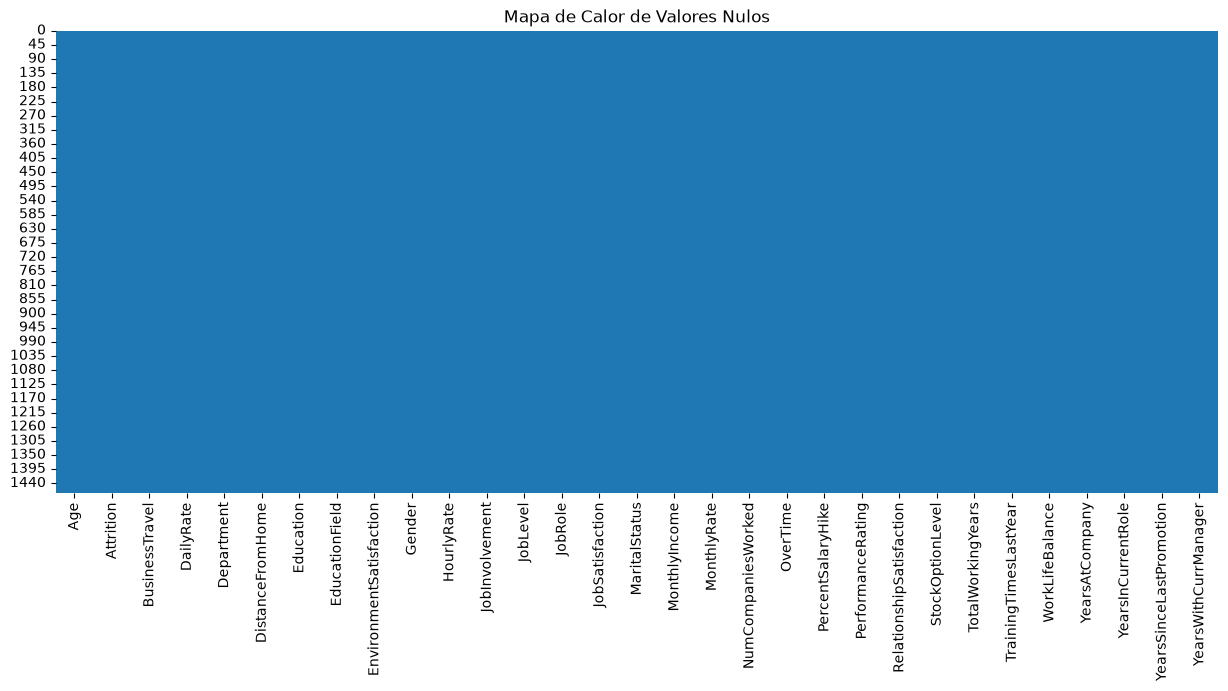

In [7]:
# Heatmap de Valores Nulos
plt.figure(figsize=(15, 6))
sns.heatmap(df.isna(), cmap=['#1f77b4', '#ff7f0e'], cbar=False)
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

Como se puede observar dentro del mapa de calor no se encuentran ningún valor nulo dentro de ninguna de las variables del conjunto de datos. 

##### Distribución de Variables

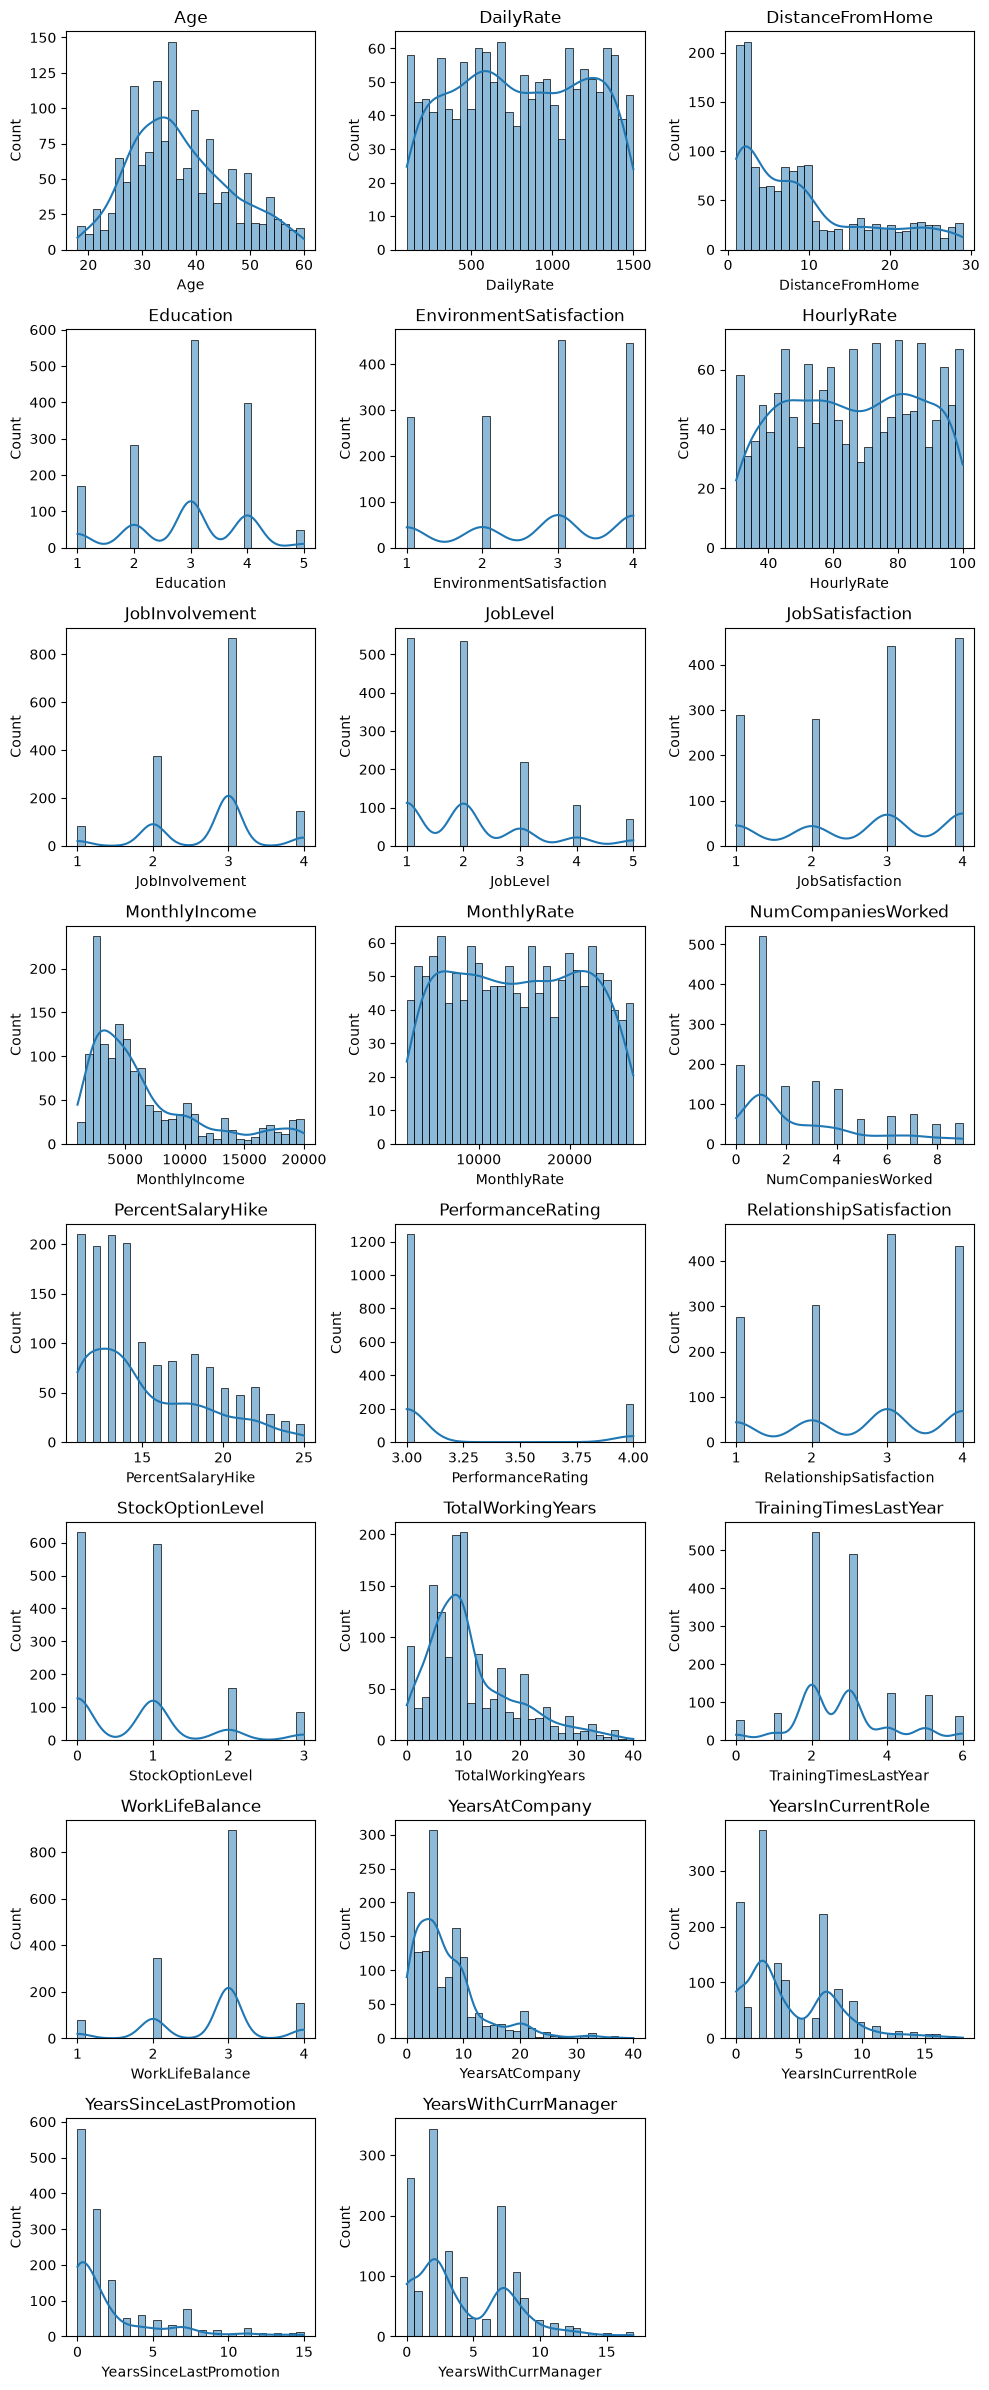

In [19]:
# Graficar columnas numéricas utilizando histogramas
num_cols = df.select_dtypes(include='number').columns # Seleccionar columnas numéricas

fig, axes = plt.subplots(
    nrows=(len(num_cols) + 2) // 3,
    ncols=3,
    figsize=(10, 3 * ((len(num_cols) + 2) // 3))
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

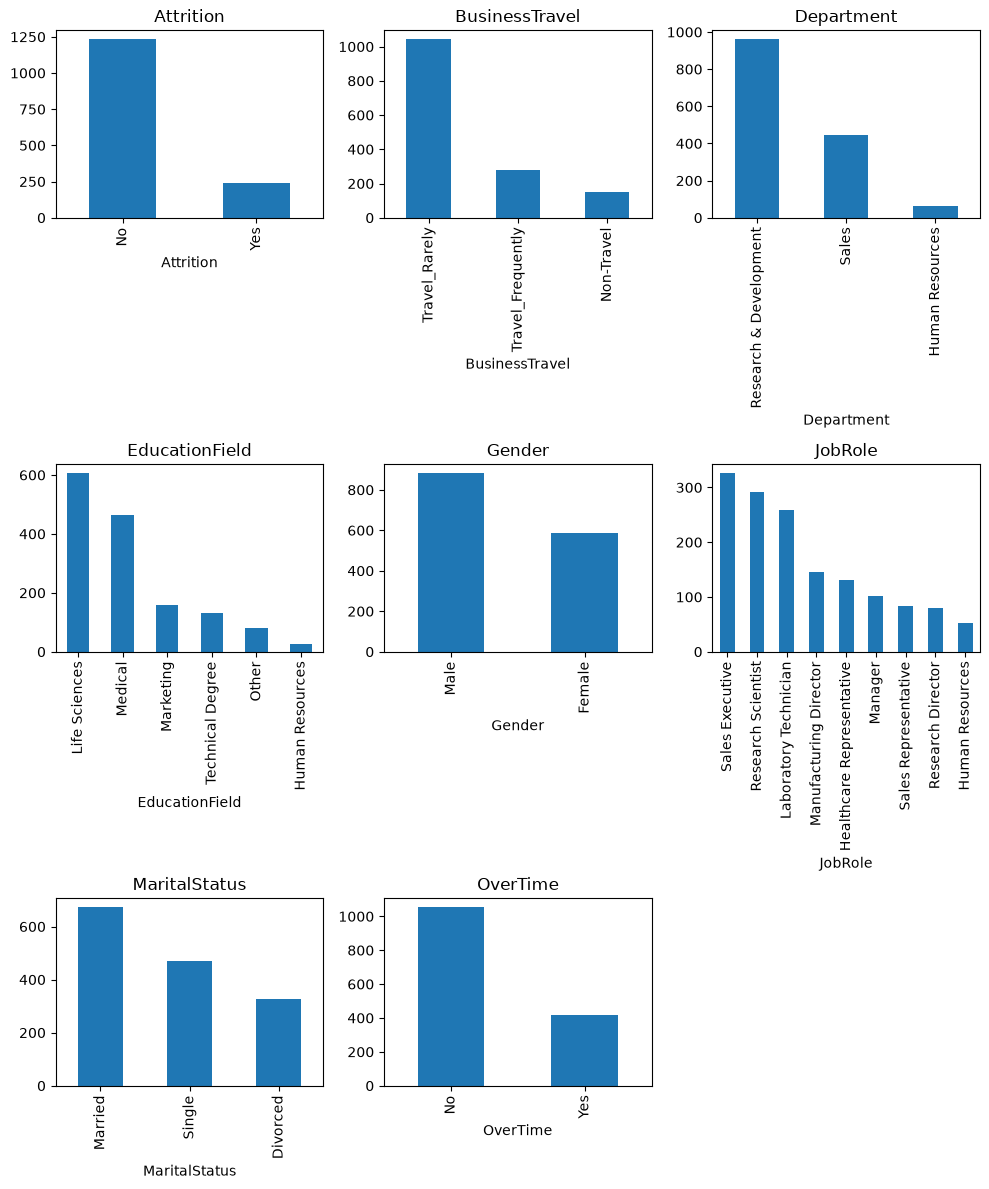

In [23]:
#Graficar columnas categóricas utilizando gráficos de barras
cat_cols = df.select_dtypes(exclude='number').columns # Seleccionar columnas categóricas

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        title=col
    )
    axes[i].tick_params(axis='x', rotation=90)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### 2.3 Análisis de la Variable Objetivo

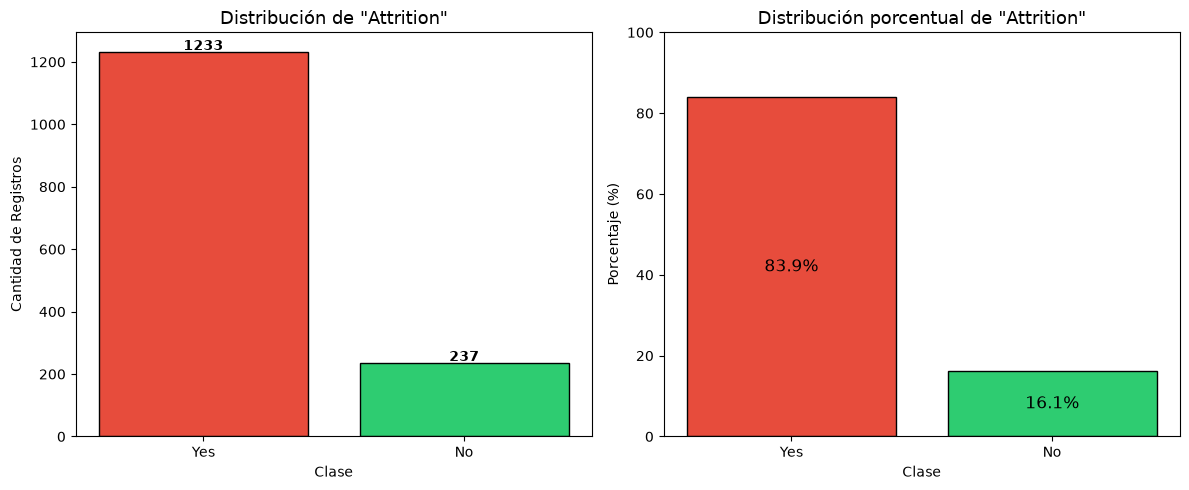

In [27]:
etiquetas = ['Yes', 'No']
colores = ['#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(12,5))
attrition = df["Attrition"].value_counts().sort_index() # Obtener valores de la variable objetivo
attrition_porc = df["Attrition"].value_counts(normalize=True).sort_index() * 100 # Obtener valores de la variable objetivo como porcentajes

# Grafico 1 - Frecuencia Absoluta
axes[0].bar(etiquetas, attrition.values, color=colores, edgecolor='black')
axes[0].set_title('Distribución de "Attrition"', fontsize=13)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de Registros')
for i,v in enumerate(attrition.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Grafico 2 - Porcentaje 
axes[1].bar(etiquetas, attrition_porc.values, color=colores, edgecolor='black')
axes[1].set_title('Distribución porcentual de "Attrition"', fontsize=13)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(attrition_porc.values):
    axes[1].text(i, v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('grafico_distribucion_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

##### 2.4 Exploración de Variables Relevantes

### **3. Preparación de los Datos**

### **4. Modelado**

### **5. Evalución**

### **6. Despliegue**